In [1]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp
# from xarrayutils.plotting import linear_piecewise_scale


In [2]:


Pred_path_1wm = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #temp warming 1 w/m2
Pred_path_025wm = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce7_5x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #temp warming .5 w/m2
Pred_path_05wm = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce15x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #all warming .5 w/m2
Pred_path_0wm = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #temp warming .5 w/m2

warming = False
if warming:
    suffix = "_warming"
else:
    suffix = ""

In [8]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

levels = 19
emulation_stability=True
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data/", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7303))

else:
    ds_groundtruth = ds_input.isel(time=slice(2903, 3503)).isel(lev=slice(None, levels))

ls = ['thetao', 'so', 'zos']



ds_prediction_raw_1wm = xr.open_zarr(Pred_path_1wm).isel(time = slice(0,7200))
ds_prediction_raw_05wm = xr.open_zarr(Pred_path_05wm)
ds_prediction_raw_025wm = xr.open_zarr(Pred_path_025wm)
ds_prediction_raw_0wm = xr.open_zarr(Pred_path_0wm).isel(time = slice(0,7200))

ds_prediction_1wm = post_processor(
    ds_prediction_raw_1wm, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_1wm.time.size)), ls
)

ds_prediction_05wm = post_processor(
    ds_prediction_raw_05wm, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_05wm.time.size)), ls
)

ds_prediction_025wm = post_processor(
    ds_prediction_raw_025wm, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_025wm.time.size)), ls
)

ds_prediction_0wm = post_processor(
    ds_prediction_raw_0wm, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_0wm.time.size)), ls
)

# Run the test to make sure the output is formatted correctly
ds_prediction_1wm = ds_prediction_1wm.transpose('time','lev',...)
ds_prediction_05wm = ds_prediction_05wm.transpose('time','lev',...)
ds_prediction_025wm = ds_prediction_025wm.transpose('time','lev',...)
ds_prediction_0wm = ds_prediction_0wm.transpose('time','lev',...)

In [9]:
ds_prediction_1wm['y']  = ds_prediction_1wm.y.assign_attrs(long_name='latitude')
ds_prediction_1wm['x']  = ds_prediction_1wm.x.assign_attrs(long_name='longitude')
ds_prediction_1wm['thetao'] = ds_prediction_1wm['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")

ds_prediction_05wm['y']  = ds_prediction_05wm.y.assign_attrs(long_name='latitude')
ds_prediction_05wm['x']  = ds_prediction_05wm.x.assign_attrs(long_name='longitude')
ds_prediction_05wm['thetao'] = ds_prediction_05wm['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")

ds_prediction_025wm['y']  = ds_prediction_025wm.y.assign_attrs(long_name='latitude')
ds_prediction_025wm['x']  = ds_prediction_025wm.x.assign_attrs(long_name='longitude')
ds_prediction_025wm['thetao'] = ds_prediction_025wm['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")

ds_prediction_0wm['y']  = ds_prediction_0wm.y.assign_attrs(long_name='latitude')
ds_prediction_0wm['x']  = ds_prediction_0wm.x.assign_attrs(long_name='longitude')
ds_prediction_0wm['thetao'] = ds_prediction_0wm['thetao'].assign_attrs(long_name = 'Temperature', units = r"${^oC}$")

In [10]:
colors = ['0.5','gold','orange','red']

/state/partition1/job-50935175/ipykernel_3852663/2036057546.py:4: UserWarning: `natural_earth_v4_1_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50
/ext3/miniconda3/lib/python3.10/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


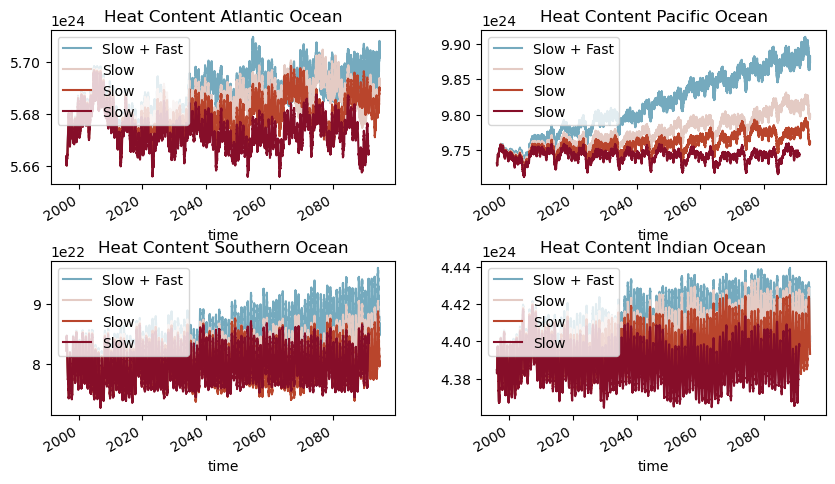

In [28]:
# Compute Basin Heat Content Time Series
Days_to_Eq = 1000

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins,ds_prediction_1wm.drop_vars(['lat','lon']))

atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

masks = atlantic_mask.to_dataset(name='Atlantic')
masks['Pacific']  = pacific_mask
masks['Southern'] = southern_ocean_mask
masks['Indian'] = indian_ocean_mask

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred_1wm = ((ds_prediction_1wm['thetao']*c_p*rho_0*masks[var])*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev'])    
    OHC_pred_1wm.plot(ax = ax_flat[i], label = 'Slow + Fast', c = colors[-1])

    OHC_pred_05wm = ((ds_prediction_05wm['thetao']*c_p*rho_0*masks[var])*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev'])    
    OHC_pred_05wm.plot(ax = ax_flat[i], label = 'Slow', c = colors[-2])
    
    OHC_pred_025wm = ((ds_prediction_025wm['thetao']*c_p*rho_0*masks[var])*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev'])    
    OHC_pred_025wm.plot(ax = ax_flat[i], label = 'Slow', c = colors[2])  

    OHC_pred_0wm = ((ds_prediction_0wm['thetao']*c_p*rho_0*masks[var])*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev'])    
    OHC_pred_0wm.plot(ax = ax_flat[i], label = 'Slow', c = colors[3])  
    
    ax_flat[i].legend()
    ax_flat[i].set_title("Heat Content " + var + " Ocean")
    # coeffs_OHC_pred_trend_1wm = np.polyfit(np.arange(OHC_pred_1wm[Days_to_Eq:].size), OHC_pred_1wm[Days_to_Eq:], 1)
    # ax_flat[i].plot(OHC_pred_1wm[Days_to_Eq:].time.data, np.arange(OHC_pred_1wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_1wm[0] + coeffs_OHC_pred_trend_1wm[1],c = colors[-1], ls = '--')
    
    # coeffs_OHC_pred_trend_05wm= np.polyfit(np.arange(OHC_pred_05wm[Days_to_Eq:].size), OHC_pred_05wm[Days_to_Eq:], 1)
    # ax_flat[i].plot(OHC_pred_05wm[Days_to_Eq:].time.data, np.arange(OHC_pred_05wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_05wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')
   
    # coeffs_OHC_pred_trend_025wm= np.polyfit(np.arange(OHC_pred_025wm[Days_to_Eq:].size), OHC_pred_025wm[Days_to_Eq:], 1)
    # ax_flat[i].plot(OHC_pred_025wm[Days_to_Eq:].time.data, np.arange(OHC_pred_025wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_025wm[0] + coeffs_OHC_pred_trend_025wm[1],c = colors[-1], ls = '--')
    
    # coeffs_OHC_pred_trend_0wm= np.polyfit(np.arange(OHC_pred_0wm[Days_to_Eq:].size), OHC_pred_0wm[Days_to_Eq:], 1)
    # ax_flat[i].plot(OHC_pred_0wm[Days_to_Eq:].time.data, np.arange(OHC_pred_0wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_0wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')

# plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Basins_OHC_Salinity_Long.png", bbox_inches='tight')


In [ ]:
# Compute Basin Heat Content Time Series

Days_to_Eq = 0
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred_upper_1wm = ((ds_prediction_1wm['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()    
OHC_pred_upper_1wm = OHC_pred_upper_1wm.rename('OHC Upper 700m')
OHC_pred_upper_1wm = OHC_pred_upper_1wm.assign_attrs(units = 'J')

OHC_pred_upper_1wm.plot(ax = ax[0], label = r"${1 \frac{w}{m^2}}$", c = colors[-1])

OHC_pred_upper_05wm = ((ds_prediction_05wm['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute() 
OHC_pred_upper_05wm = OHC_pred_upper_05wm.rename('OHC Upper 700m')
OHC_pred_upper_05wm = OHC_pred_upper_05wm.assign_attrs(units = 'J')

OHC_pred_upper_05wm.plot(ax = ax[0], label = r"${0.5 \frac{w}{m^2}}$", c = colors[-2])

OHC_pred_upper_025wm = ((ds_prediction_025wm['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute() 
OHC_pred_upper_025wm = OHC_pred_upper_025wm.rename('OHC Upper 700m')
OHC_pred_upper_025wm = OHC_pred_upper_025wm.assign_attrs(units = 'J')

OHC_pred_upper_025wm.plot(ax = ax[0], label = r"${0.25 \frac{w}{m^2}}$", c = colors[-3])

OHC_pred_upper_0wm = ((ds_prediction_0wm['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute() 
OHC_pred_upper_0wm = OHC_pred_upper_0wm.rename('OHC Upper 700m')
OHC_pred_upper_0wm = OHC_pred_upper_0wm.assign_attrs(units = 'J')

OHC_pred_upper_0wm.plot(ax = ax[0], label = r"${0 \frac{w}{m^2}}$", c = colors[-4])

# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend_1wm= np.polyfit(np.arange(OHC_pred_upper_1wm[Days_to_Eq:].size), OHC_pred_upper_1wm[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_1wm[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_1wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_1wm[0] + coeffs_OHC_pred_trend_1wm[1],c = colors[-1], ls = '--')
coeffs_OHC_pred_trend_05wm= np.polyfit(np.arange(OHC_pred_upper_05wm[Days_to_Eq:].size), OHC_pred_upper_05wm[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_05wm[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_05wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_05wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')
coeffs_OHC_pred_trend_025wm= np.polyfit(np.arange(OHC_pred_upper_025wm[Days_to_Eq:].size), OHC_pred_upper_025wm[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_025wm[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_025wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_025wm[0] + coeffs_OHC_pred_trend_025wm[1],c = colors[-3], ls = '--')
coeffs_OHC_pred_trend_0wm= np.polyfit(np.arange(OHC_pred_upper_0wm[Days_to_Eq:].size), OHC_pred_upper_0wm[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_0wm[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_0wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_0wm[0] + coeffs_OHC_pred_trend_0wm[1],c = colors[-4], ls = '--')
ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
ax[0].legend(loc = "upper left",ncol =2)



OHC_pred_mid_1wm = ((ds_prediction_1wm['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_mid_1wm = OHC_pred_mid_1wm.rename('OHC  0.7-2km')
OHC_pred_mid_1wm = OHC_pred_mid_1wm.assign_attrs(units = 'J')

OHC_pred_mid_1wm.plot(ax = ax[1], label = 'slow + fast', c = colors[-1])

OHC_pred_mid_05wm = ((ds_prediction_05wm['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()    
OHC_pred_mid_05wm = OHC_pred_mid_05wm.rename('OHC  0.7-2km')
OHC_pred_mid_05wm = OHC_pred_mid_05wm.assign_attrs(units = 'J')

OHC_pred_mid_05wm.plot(ax = ax[1], label = 'slow', c = colors[-2])

OHC_pred_mid_025wm = ((ds_prediction_025wm['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()    
OHC_pred_mid_025wm = OHC_pred_mid_025wm.rename('OHC  0.7-2km')
OHC_pred_mid_025wm = OHC_pred_mid_025wm.assign_attrs(units = 'J')

OHC_pred_mid_025wm.plot(ax = ax[1], label = 'slow', c = colors[-3])

OHC_pred_mid_0wm = ((ds_prediction_0wm['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()    
OHC_pred_mid_0wm = OHC_pred_mid_0wm.rename('OHC  0.7-2km')
OHC_pred_mid_0wm = OHC_pred_mid_0wm.assign_attrs(units = 'J')

OHC_pred_mid_0wm.plot(ax = ax[1], label = 'slow', c = colors[-4])

ax[1].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend_1wm= np.polyfit(np.arange(OHC_pred_mid_1wm[Days_to_Eq:].size), OHC_pred_mid_1wm[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_1wm[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_1wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_1wm[0] + coeffs_OHC_pred_trend_1wm[1],c = colors[-1], ls = '--')
coeffs_OHC_pred_trend_05wm= np.polyfit(np.arange(OHC_pred_mid_05wm[Days_to_Eq:].size), OHC_pred_mid_05wm[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_05wm[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_05wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_05wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')
coeffs_OHC_pred_trend_025wm= np.polyfit(np.arange(OHC_pred_mid_025wm[Days_to_Eq:].size), OHC_pred_mid_025wm[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_025wm[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_025wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_025wm[0] + coeffs_OHC_pred_trend_025wm[1],c = colors[-3], ls = '--')
coeffs_OHC_pred_trend_0wm= np.polyfit(np.arange(OHC_pred_mid_0wm[Days_to_Eq:].size), OHC_pred_mid_0wm[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_0wm[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_0wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_0wm[0] + coeffs_OHC_pred_trend_0wm[1],c = colors[-4], ls = '--')
ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)


OHC_pred_deep_1wm = ((ds_prediction_1wm['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_1wm = OHC_pred_deep_1wm.rename('OHC 2km to bottom')
OHC_pred_deep_1wm = OHC_pred_deep_1wm.assign_attrs(units = 'J')

OHC_pred_deep_1wm.plot(ax = ax[2], label = 'slow + fast', c = colors[-1])

OHC_pred_deep_05wm = ((ds_prediction_05wm['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_05wm = OHC_pred_deep_05wm.rename('OHC 2km to bottom')
OHC_pred_deep_05wm = OHC_pred_deep_05wm.assign_attrs(units = 'J')

OHC_pred_deep_05wm.plot(ax = ax[2], label = 'slow', c = colors[-2])

OHC_pred_deep_025wm = ((ds_prediction_025wm['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_025wm = OHC_pred_deep_025wm.rename('OHC 2km to bottom')
OHC_pred_deep_025wm = OHC_pred_deep_025wm.assign_attrs(units = 'J')

OHC_pred_deep_025wm.plot(ax = ax[2], label = 'slow', c = colors[-3])

OHC_pred_deep_0wm = ((ds_prediction_0wm['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_0wm = OHC_pred_deep_0wm.rename('OHC 2km to bottom')
OHC_pred_deep_0wm = OHC_pred_deep_0wm.assign_attrs(units = 'J')

OHC_pred_deep_0wm.plot(ax = ax[2], label = 'slow', c = colors[-4])


# ax[0].legend()
ax[2].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend_1wm= np.polyfit(np.arange(OHC_pred_deep_1wm[Days_to_Eq:].size), OHC_pred_deep_1wm[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_1wm[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_1wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_1wm[0] + coeffs_OHC_pred_trend_1wm[1],c = colors[-1], ls = '--')
coeffs_OHC_pred_trend_05wm= np.polyfit(np.arange(OHC_pred_deep_05wm[Days_to_Eq:].size), OHC_pred_deep_05wm[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_05wm[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_05wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_05wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')
coeffs_OHC_pred_trend_025wm= np.polyfit(np.arange(OHC_pred_deep_025wm[Days_to_Eq:].size), OHC_pred_deep_025wm[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_025wm[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_025wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_025wm[0] + coeffs_OHC_pred_trend_025wm[1],c = colors[-3], ls = '--')
coeffs_OHC_pred_trend_0wm= np.polyfit(np.arange(OHC_pred_deep_0wm[Days_to_Eq:].size), OHC_pred_deep_0wm[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_0wm[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_0wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_0wm[0] + coeffs_OHC_pred_trend_0wm[1],c = colors[-4], ls = '--')
ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)


# plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Depth_OHC_Warming_Comparison.png", bbox_inches='tight')


/state/partition1/job-50976413/ipykernel_279835/2072684053.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
/state/partition1/job-50976413/ipykernel_279835/2072684053.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)
/state/partition1/job-50976413/ipykernel_279835/2072684053.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)


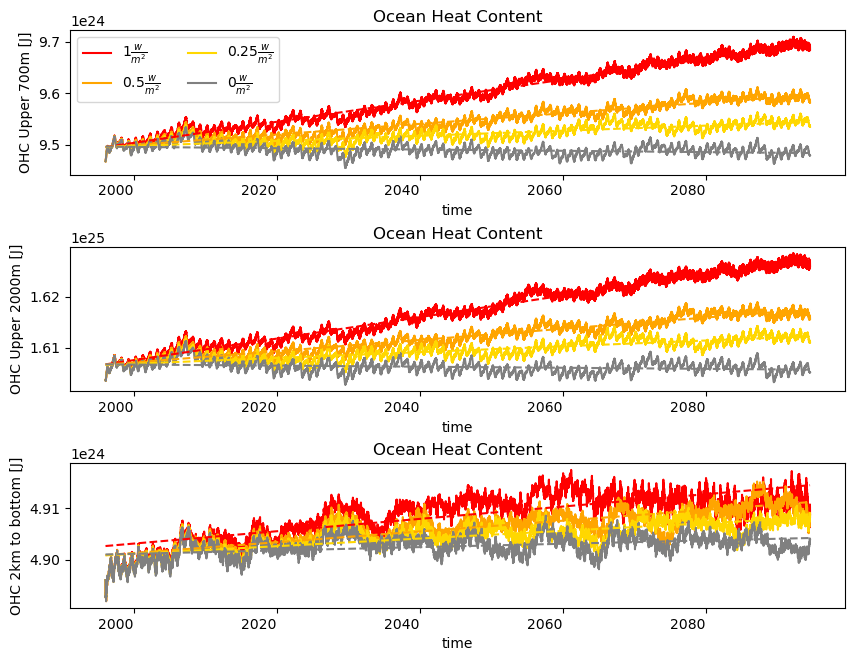

In [12]:
# Compute Basin Heat Content Time Series

Days_to_Eq = 0
c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred_upper_1wm = ((ds_prediction_1wm['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()    
OHC_pred_upper_1wm = OHC_pred_upper_1wm.rename('OHC Upper 700m')
OHC_pred_upper_1wm = OHC_pred_upper_1wm.assign_attrs(units = 'J')

OHC_pred_upper_1wm.plot(ax = ax[0], label = r"${1 \frac{w}{m^2}}$", c = colors[-1])

OHC_pred_upper_05wm = ((ds_prediction_05wm['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute() 
OHC_pred_upper_05wm = OHC_pred_upper_05wm.rename('OHC Upper 700m')
OHC_pred_upper_05wm = OHC_pred_upper_05wm.assign_attrs(units = 'J')

OHC_pred_upper_05wm.plot(ax = ax[0], label = r"${0.5 \frac{w}{m^2}}$", c = colors[-2])

OHC_pred_upper_025wm = ((ds_prediction_025wm['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute() 
OHC_pred_upper_025wm = OHC_pred_upper_025wm.rename('OHC Upper 700m')
OHC_pred_upper_025wm = OHC_pred_upper_025wm.assign_attrs(units = 'J')

OHC_pred_upper_025wm.plot(ax = ax[0], label = r"${0.25 \frac{w}{m^2}}$", c = colors[-3])

OHC_pred_upper_0wm = ((ds_prediction_0wm['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute() 
OHC_pred_upper_0wm = OHC_pred_upper_0wm.rename('OHC Upper 700m')
OHC_pred_upper_0wm = OHC_pred_upper_0wm.assign_attrs(units = 'J')

OHC_pred_upper_0wm.plot(ax = ax[0], label = r"${0 \frac{w}{m^2}}$", c = colors[-4])

# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend_1wm= np.polyfit(np.arange(OHC_pred_upper_1wm[Days_to_Eq:].size), OHC_pred_upper_1wm[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_1wm[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_1wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_1wm[0] + coeffs_OHC_pred_trend_1wm[1],c = colors[-1], ls = '--')
coeffs_OHC_pred_trend_05wm= np.polyfit(np.arange(OHC_pred_upper_05wm[Days_to_Eq:].size), OHC_pred_upper_05wm[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_05wm[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_05wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_05wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')
coeffs_OHC_pred_trend_025wm= np.polyfit(np.arange(OHC_pred_upper_025wm[Days_to_Eq:].size), OHC_pred_upper_025wm[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_025wm[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_025wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_025wm[0] + coeffs_OHC_pred_trend_025wm[1],c = colors[-3], ls = '--')
coeffs_OHC_pred_trend_0wm= np.polyfit(np.arange(OHC_pred_upper_0wm[Days_to_Eq:].size), OHC_pred_upper_0wm[Days_to_Eq:], 1)
ax[0].plot(OHC_pred_upper_0wm[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_0wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_0wm[0] + coeffs_OHC_pred_trend_0wm[1],c = colors[-4], ls = '--')
ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
ax[0].legend(loc = "upper left",ncol = 2)



OHC_pred_mid_1wm = ((ds_prediction_1wm['thetao'].sel(lev = slice(0,2000))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_mid_1wm = OHC_pred_mid_1wm.rename('OHC Upper 2000m')
OHC_pred_mid_1wm = OHC_pred_mid_1wm.assign_attrs(units = 'J')

OHC_pred_mid_1wm.plot(ax = ax[1], label = 'slow + fast', c = colors[-1])

OHC_pred_mid_05wm = ((ds_prediction_05wm['thetao'].sel(lev = slice(0,2000))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()    
OHC_pred_mid_05wm = OHC_pred_mid_05wm.rename('OHC Upper 2000m')
OHC_pred_mid_05wm = OHC_pred_mid_05wm.assign_attrs(units = 'J')

OHC_pred_mid_05wm.plot(ax = ax[1], label = 'slow', c = colors[-2])

OHC_pred_mid_025wm = ((ds_prediction_025wm['thetao'].sel(lev = slice(0,2000))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()    
OHC_pred_mid_025wm = OHC_pred_mid_025wm.rename('OHC Upper 2000m')
OHC_pred_mid_025wm = OHC_pred_mid_025wm.assign_attrs(units = 'J')

OHC_pred_mid_025wm.plot(ax = ax[1], label = 'slow', c = colors[-3])

OHC_pred_mid_0wm = ((ds_prediction_0wm['thetao'].sel(lev = slice(0,2000))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()    
OHC_pred_mid_0wm = OHC_pred_mid_0wm.rename('OHC Upper 2000m')
OHC_pred_mid_0wm = OHC_pred_mid_0wm.assign_attrs(units = 'J')

OHC_pred_mid_0wm.plot(ax = ax[1], label = 'slow', c = colors[-4])

ax[1].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend_1wm= np.polyfit(np.arange(OHC_pred_mid_1wm[Days_to_Eq:].size), OHC_pred_mid_1wm[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_1wm[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_1wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_1wm[0] + coeffs_OHC_pred_trend_1wm[1],c = colors[-1], ls = '--')
coeffs_OHC_pred_trend_05wm= np.polyfit(np.arange(OHC_pred_mid_05wm[Days_to_Eq:].size), OHC_pred_mid_05wm[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_05wm[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_05wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_05wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')
coeffs_OHC_pred_trend_025wm= np.polyfit(np.arange(OHC_pred_mid_025wm[Days_to_Eq:].size), OHC_pred_mid_025wm[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_025wm[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_025wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_025wm[0] + coeffs_OHC_pred_trend_025wm[1],c = colors[-3], ls = '--')
coeffs_OHC_pred_trend_0wm= np.polyfit(np.arange(OHC_pred_mid_0wm[Days_to_Eq:].size), OHC_pred_mid_0wm[Days_to_Eq:], 1)
ax[1].plot(OHC_pred_mid_0wm[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_0wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_0wm[0] + coeffs_OHC_pred_trend_0wm[1],c = colors[-4], ls = '--')
ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)


OHC_pred_deep_1wm = ((ds_prediction_1wm['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_1wm = OHC_pred_deep_1wm.rename('OHC 2km to bottom')
OHC_pred_deep_1wm = OHC_pred_deep_1wm.assign_attrs(units = 'J')

OHC_pred_deep_1wm.plot(ax = ax[2], label = 'slow + fast', c = colors[-1])

OHC_pred_deep_05wm = ((ds_prediction_05wm['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_05wm = OHC_pred_deep_05wm.rename('OHC 2km to bottom')
OHC_pred_deep_05wm = OHC_pred_deep_05wm.assign_attrs(units = 'J')

OHC_pred_deep_05wm.plot(ax = ax[2], label = 'slow', c = colors[-2])

OHC_pred_deep_025wm = ((ds_prediction_025wm['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_025wm = OHC_pred_deep_025wm.rename('OHC 2km to bottom')
OHC_pred_deep_025wm = OHC_pred_deep_025wm.assign_attrs(units = 'J')

OHC_pred_deep_025wm.plot(ax = ax[2], label = 'slow', c = colors[-3])

OHC_pred_deep_0wm = ((ds_prediction_0wm['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_1wm['areacello']*ds_prediction_1wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_deep_0wm = OHC_pred_deep_0wm.rename('OHC 2km to bottom')
OHC_pred_deep_0wm = OHC_pred_deep_0wm.assign_attrs(units = 'J')

OHC_pred_deep_0wm.plot(ax = ax[2], label = 'slow', c = colors[-4])


# ax[0].legend()
ax[2].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend_1wm= np.polyfit(np.arange(OHC_pred_deep_1wm[Days_to_Eq:].size), OHC_pred_deep_1wm[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_1wm[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_1wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_1wm[0] + coeffs_OHC_pred_trend_1wm[1],c = colors[-1], ls = '--')
coeffs_OHC_pred_trend_05wm= np.polyfit(np.arange(OHC_pred_deep_05wm[Days_to_Eq:].size), OHC_pred_deep_05wm[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_05wm[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_05wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_05wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')
coeffs_OHC_pred_trend_025wm= np.polyfit(np.arange(OHC_pred_deep_025wm[Days_to_Eq:].size), OHC_pred_deep_025wm[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_025wm[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_025wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_025wm[0] + coeffs_OHC_pred_trend_025wm[1],c = colors[-3], ls = '--')
coeffs_OHC_pred_trend_0wm= np.polyfit(np.arange(OHC_pred_deep_0wm[Days_to_Eq:].size), OHC_pred_deep_0wm[Days_to_Eq:], 1)
ax[2].plot(OHC_pred_deep_0wm[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_0wm[Days_to_Eq:].size)*coeffs_OHC_pred_trend_0wm[0] + coeffs_OHC_pred_trend_0wm[1],c = colors[-4], ls = '--')
ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)


plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Depth_OHC_Warming_Comparison.png", bbox_inches='tight')


In [ ]:
Days_to_Eq = 0

c_p = 3850 #J/(kg C) 
rho_0 = 1025 #kg/m^3

fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})

OHC_pred_1wm = ((ds_prediction_1wm['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_05wm['areacello']*ds_prediction_05wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_1wm = OHC_pred_1wm.rename('Ocean Heat Content')
OHC_pred_1wm = OHC_pred_1wm.assign_attrs(units = 'J')

OHC_pred_1wm.plot(ax = ax[0], label = r"${1 \frac{w}{m^2}}$", c = colors[-1])

OHC_pred_05wm = ((ds_prediction_05wm['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_05wm['areacello']*ds_prediction_05wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_05wm = OHC_pred_05wm.rename('Ocean Heat Content')
OHC_pred_05wm = OHC_pred_05wm.assign_attrs(units = 'J')

OHC_pred_05wm.plot(ax = ax[0], label = r"${0.5 \frac{w}{m^2}}$", c = colors[-2])

OHC_pred_025wm = ((ds_prediction_025wm['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_025wm['areacello']*ds_prediction_025wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_025wm = OHC_pred_025wm.rename('Ocean Heat Content')
OHC_pred_025wm = OHC_pred_025wm.assign_attrs(units = 'J')

OHC_pred_025wm.plot(ax = ax[0], label = r"${0.25 \frac{w}{m^2}}$", c = colors[-3])

OHC_pred_0wm = ((ds_prediction_0wm['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_0wm['areacello']*ds_prediction_0wm['dz']).sum(['x','y','lev']).compute()     
OHC_pred_0wm = OHC_pred_0wm.rename('Ocean Heat Content')
OHC_pred_0wm = OHC_pred_0wm.assign_attrs(units = 'J')

OHC_pred_0wm.plot(ax = ax[0], label = r"${0 \frac{w}{m^2}}$", c = colors[-4])

# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend_1wm= np.polyfit(np.arange(OHC_pred_1wm[:].size), OHC_pred_1wm[:], 1)
ax[0].plot(OHC_pred_1wm[:].time.data, np.arange(OHC_pred_1wm[:].size)*coeffs_OHC_pred_trend_1wm[0] + coeffs_OHC_pred_trend_1wm[1],c = colors[-1], ls = '--')
coeffs_OHC_pred_trend_05wm= np.polyfit(np.arange(OHC_pred_05wm[:].size), OHC_pred_05wm[:], 1)
ax[0].plot(OHC_pred_05wm[:].time.data, np.arange(OHC_pred_05wm[:].size)*coeffs_OHC_pred_trend_05wm[0] + coeffs_OHC_pred_trend_05wm[1],c = colors[-2], ls = '--')
coeffs_OHC_pred_trend_025wm= np.polyfit(np.arange(OHC_pred_025wm[:].size), OHC_pred_025wm[:], 1)
ax[0].plot(OHC_pred_025wm[:].time.data, np.arange(OHC_pred_025wm[:].size)*coeffs_OHC_pred_trend_025wm[0] + coeffs_OHC_pred_trend_025wm[1],c = colors[-3], ls = '--')
coeffs_OHC_pred_trend_0wm= np.polyfit(np.arange(OHC_pred_0wm[:].size), OHC_pred_0wm[:], 1)
ax[0].plot(OHC_pred_0wm[:].time.data, np.arange(OHC_pred_0wm[:].size)*coeffs_OHC_pred_trend_0wm[0] + coeffs_OHC_pred_trend_0wm[1],c = colors[-4], ls = '--')
ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
ax[0].set_xlabel('')

ax[0].legend(loc = 'upper left')

salinity_1wm = ((ds_prediction_1wm['so'][Days_to_Eq:]*rho_0)*ds_prediction_05wm['areacello']*ds_prediction_05wm['dz']).sum(['x','y','lev']).compute()     
salinity_1wm = salinity_1wm.rename('salinity_1wm')
salinity_1wm = salinity_1wm.assign_attrs(units = 'g')

salinity_1wm.plot(ax = ax[1], label = 'slow + fast', c = colors[-1])


salinity_05wm = ((ds_prediction_05wm['so'][Days_to_Eq:]*rho_0)*ds_prediction_05wm['areacello']*ds_prediction_05wm['dz']).sum(['x','y','lev']).compute()     
salinity_05wm = salinity_05wm.rename('Salinity')
salinity_05wm = salinity_05wm.assign_attrs(units = 'g')

salinity_05wm.plot(ax = ax[1], label = 'slow', c = colors[-2])

salinity_025wm = ((ds_prediction_025wm['so'][Days_to_Eq:]*rho_0)*ds_prediction_025wm['areacello']*ds_prediction_025wm['dz']).sum(['x','y','lev']).compute()     
salinity_025wm = salinity_025wm.rename('Salinity')
salinity_025wm = salinity_025wm.assign_attrs(units = 'g')

salinity_025wm.plot(ax = ax[1], label = 'slow', c = colors[-3])

salinity_0wm = ((ds_prediction_0wm['so'][Days_to_Eq:]*rho_0)*ds_prediction_0wm['areacello']*ds_prediction_0wm['dz']).sum(['x','y','lev']).compute()     
salinity_0wm = salinity_0wm.rename('Salinity')
salinity_0wm = salinity_0wm.assign_attrs(units = 'g')

salinity_0wm.plot(ax = ax[1], label = 'slow', c = colors[-4])

# ax[1].legend()
ax[1].set_title("Ocean Total Salinity")

coeffs_salinity_trend_1wm= np.polyfit(np.arange(salinity_1wm[:].size), salinity_1wm[:], 1)
ax[1].plot(salinity_1wm[:].time.data, np.arange(salinity_1wm[:].size)*coeffs_salinity_trend_1wm[0] + coeffs_salinity_trend_1wm[1],c = colors[-1], ls = '--')

coeffs_salinity_trend_05wm= np.polyfit(np.arange(salinity_05wm[:].size), salinity_05wm[:], 1)
ax[1].plot(salinity_05wm[:].time.data, np.arange(salinity_05wm[:].size)*coeffs_salinity_trend_05wm[0] + coeffs_salinity_trend_05wm[1],c = colors[-2], ls = '--')

coeffs_salinity_trend_025wm= np.polyfit(np.arange(salinity_025wm[:].size), salinity_025wm[:], 1)
ax[1].plot(salinity_025wm[:].time.data, np.arange(salinity_025wm[:].size)*coeffs_salinity_trend_025wm[0] + coeffs_salinity_trend_025wm[1],c = colors[-2], ls = '--')

coeffs_salinity_trend_0wm= np.polyfit(np.arange(salinity_0wm[:].size), salinity_0wm[:], 1)
ax[1].plot(salinity_0wm[:].time.data, np.arange(salinity_0wm[:].size)*coeffs_salinity_trend_0wm[0] + coeffs_salinity_trend_0wm[1],c = colors[-2], ls = '--')
ax[1].set_ylim([5.8615e+22, 5.8625e+22])
ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)
ax[1].set_xlabel('')

print(coeffs_OHC_pred_trend_1wm[0]*73/1e21)
print(coeffs_salinity_trend_1wm[0]*73/1e17)

print(coeffs_OHC_pred_trend_05wm[0]*73/1e21)
print(coeffs_salinity_trend_05wm[0]*73/1e17)

print(coeffs_OHC_pred_trend_025wm[0]*73/1e21)
print(coeffs_salinity_trend_025wm[0]*73/1e17)

print(coeffs_OHC_pred_trend_0wm[0]*73/1e21)
print(coeffs_salinity_trend_0wm[0]*73/1e17)
plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/OHC_Salinity_Long_warming.png", bbox_inches='tight')



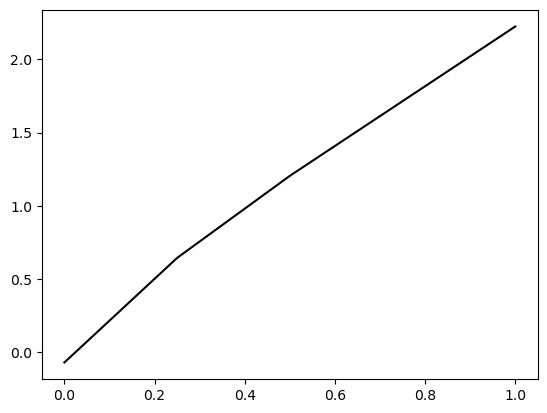

In [8]:
forcings = np.array([0, 0.25, 0.5, 1])
response = np.array([-0.0712105740226767, 0.6436487979976098, 1.204786306831478, 2.225734327367153])
plt.plot(forcings,response,'k')
